In [1]:
# ============================================================
# MODELO QSAR — ALTA POTENCIA v3 (clustering GMM, n=3)
# Umbral: Log10 EC50 ≤ 4.5 nM
#
# BIC: n=2→673.8, n=3→603.6, n=4→618.4  → n=3 óptimo
#
# Clusters identificados:
#   C0: media=3.350  std=0.317  n≈101  (3.0–3.7)
#   C1: media=3.894  std=0.159  n≈333  (3.7–4.1)
#   C2: media=4.336  std=0.100  n≈259  (4.1–4.5)
#
# Mismo patrón que funcionó en Baja v4 (R² global=0.73)
# ============================================================

# ── CELDA 1 — Instalación ─────────────────────────────────────
!pip install rdkit --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 25.3 MB/s eta 0:00:00


In [2]:
# ── CELDA 2 — Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.mixture import GaussianMixture
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib, os

from google.colab import drive

RANDOM_SEED = 42
PALETTE_C   = ["#2196F3", "#FF9800", "#4CAF50"]   # azul/naranja/verde por cluster

In [3]:
# ── CELDA 3 — Cargar y filtrar datos ─────────────────────────
drive.mount('/content/drive')

RUTA_CSV = "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/EC50_molecules_reclassified.csv"

database = pd.read_csv(RUTA_CSV)
database['Log10 Value (nM)'] = pd.to_numeric(
    database['Log10 Value (nM)'], errors='coerce'
)

df = database[database['Log10 Value (nM)'] <= 4.5].copy()
df = df[['Molecule ChEMBL ID', 'Smiles', 'Log10 Value (nM)']].dropna()
df.columns = ['chembl_id', 'smiles', 'log10_ec50']
df = df.reset_index(drop=True)

# Eliminar outliers extremos cola izquierda
y_raw = df['log10_ec50'].values
Q1, Q3 = np.percentile(y_raw, 25), np.percentile(y_raw, 75)
lower  = Q1 - 2.5 * (Q3 - Q1)
df     = df[df['log10_ec50'] >= lower].reset_index(drop=True)

print(f"Alta Potencia (Log10 ≤ 4.5, sin outliers): {len(df)} moléculas")
print(df['log10_ec50'].describe().round(4))

Mounted at /content/drive
Alta Potencia (Log10 ≤ 4.5, sin outliers): 693 moléculas
count    693.0000
mean       3.9549
std        0.4192
min        2.2300
25%        3.7410
50%        4.0000
75%        4.2830
max        4.4990
Name: log10_ec50, dtype: float64



── Clustering GMM (n=3) ──
  Cluster 0: n= 101  media=3.186  std=0.317  rango=[2.230, 3.534]
  Cluster 1: n= 333  media=3.886  std=0.159  rango=[3.540, 4.155]
  Cluster 2: n= 259  media=4.344  std=0.100  rango=[4.157, 4.499]


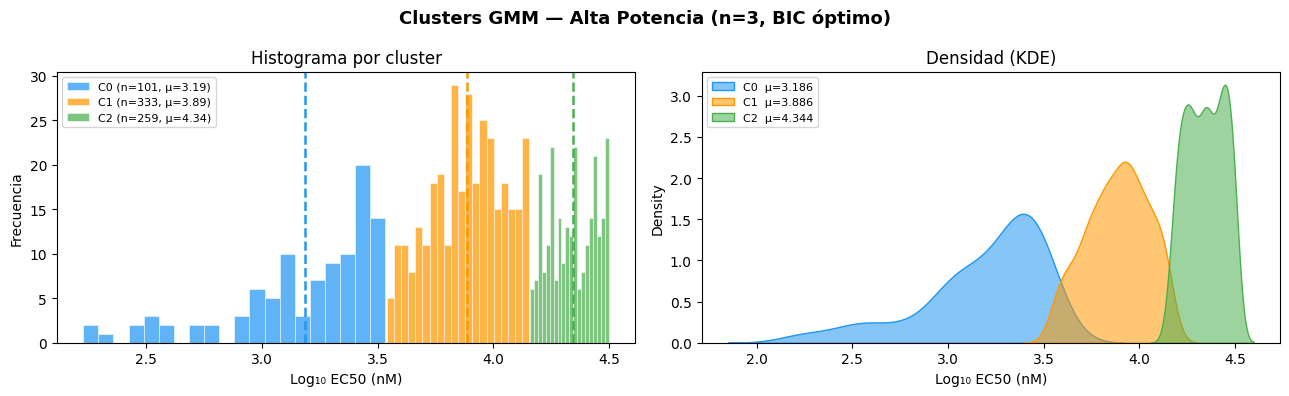

In [4]:
# ── CELDA 4 — Clustering GMM (n=3, BIC óptimo) ───────────────
print("\n── Clustering GMM (n=3) ──")

y_vals = df['log10_ec50'].values
gmm    = GaussianMixture(n_components=3, random_state=RANDOM_SEED)
gmm.fit(y_vals.reshape(-1, 1))
raw_labels = gmm.predict(y_vals.reshape(-1, 1))

# Reordenar clusters por media ascendente
order  = np.argsort(gmm.means_.flatten())
remap  = {old: new for new, old in enumerate(order)}
cluster_labels = np.array([remap[l] for l in raw_labels])

for cid in range(3):
    vals = y_vals[cluster_labels == cid]
    print(f"  Cluster {cid}: n={len(vals):4d}  "
          f"media={vals.mean():.3f}  std={vals.std():.3f}  "
          f"rango=[{vals.min():.3f}, {vals.max():.3f}]")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Clusters GMM — Alta Potencia (n=3, BIC óptimo)",
             fontsize=13, fontweight="bold")

for cid in range(3):
    vals = y_vals[cluster_labels == cid]
    axes[0].hist(vals, bins=20, color=PALETTE_C[cid], alpha=0.72,
                 edgecolor="white", linewidth=0.5,
                 label=f"C{cid} (n={len(vals)}, μ={vals.mean():.2f})")
    axes[0].axvline(vals.mean(), color=PALETTE_C[cid],
                    linestyle="--", linewidth=1.8)
    sns.kdeplot(vals, ax=axes[1], fill=True, color=PALETTE_C[cid],
                alpha=0.55, label=f"C{cid}  μ={vals.mean():.3f}")

axes[0].set_xlabel("Log₁₀ EC50 (nM)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma por cluster"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Log₁₀ EC50 (nM)"); axes[1].set_title("Densidad (KDE)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/alta_v3_clusters.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [5]:
# ── CELDA 5 — Descriptores moleculares ───────────────────────
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    fp4  = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)), dtype=float)
    fp6  = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 3, 1024)), dtype=float)
    maccs = np.array(list(rdMolDescriptors.GetMACCSKeysFingerprint(mol)), dtype=float)
    desc = [
        Descriptors.ExactMolWt(mol),       Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),             Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),    Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),     Descriptors.NumAliphaticRings(mol),
        Descriptors.NumHeteroatoms(mol),   Descriptors.HeavyAtomCount(mol),
        Descriptors.NumSaturatedRings(mol),
        rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        rdMolDescriptors.CalcNumSpiroAtoms(mol),
    ]
    return np.concatenate([fp4, fp6, maccs, desc])

print("Calculando descriptores...")
X_list, valid_idx = [], []
for i, smi in enumerate(df['smiles']):
    d = get_descriptors(smi)
    if d is not None:
        X_list.append(d); valid_idx.append(i)

X_full  = np.array(X_list)
y_full  = df['log10_ec50'].iloc[valid_idx].values
cl_all  = cluster_labels[valid_idx]
mask    = np.isfinite(y_full)
X_full, y_full, cl_all = X_full[mask], y_full[mask], cl_all[mask]
print(f"Moleculas: {len(X_full)}  |  Features: {X_full.shape[1]}")

Calculando descriptores...


[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerator
[21:16:51] DEPRECATION WARNING: please use MorganGenerat

Moleculas: 693  |  Features: 2230


[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerator
[21:16:54] DEPRECATION WARNING: please use MorganGenerat

In [6]:
# ── CELDA 6 — Limpieza de features ───────────────────────────
vt      = VarianceThreshold(threshold=0.01)
X_vt    = vt.fit_transform(X_full)
corr    = np.corrcoef(X_vt.T)
upper_t = np.triu(np.abs(corr), k=1)
drop    = np.where(np.any(upper_t > 0.95, axis=0))[0]
keep    = np.ones(X_vt.shape[1], dtype=bool); keep[drop] = False
X_clean = X_vt[:, keep]
print(f"Features: {X_full.shape[1]} -> {X_vt.shape[1]} -> {X_clean.shape[1]}")

Features: 2230 -> 1606 -> 1372


In [7]:
# ── CELDA 7 — Split global estratificado ─────────────────────
y_bins = pd.qcut(y_full, q=5, labels=False, duplicates='drop')
X_tr_all, X_te_all, y_tr_all, y_te_all, cl_tr, cl_te = train_test_split(
    X_clean, y_full, cl_all,
    test_size=0.20, random_state=RANDOM_SEED, stratify=y_bins
)
print(f"Train: {len(y_tr_all)}  |  Test: {len(y_te_all)}")
for cid in range(3):
    print(f"  C{cid}: train={(cl_tr==cid).sum()}  test={(cl_te==cid).sum()}")

Train: 554  |  Test: 139
  C0: train=83  test=18
  C1: train=262  test=71
  C2: train=209  test=50


In [8]:
# ── CELDA 8 — Funcion: mejor modelo por cluster ───────────────
def fit_best_model(X_tr, y_tr, cluster_name):
    n_cv = max(3, min(5, len(y_tr) // 10))
    kf_c = KFold(n_splits=n_cv, shuffle=True, random_state=RANDOM_SEED)
    candidates = {
        "GradientBoosting": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  GradientBoostingRegressor(
                n_estimators=500, learning_rate=0.02, max_depth=4,
                subsample=0.75, min_samples_leaf=3, max_features=0.5,
                random_state=RANDOM_SEED))
        ]),
        "RandomForest": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  RandomForestRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1))
        ]),
        "ExtraTrees": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  ExtraTreesRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1))
        ]),
        "SVM": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  SVR(kernel="rbf", C=50, epsilon=0.01, gamma="scale"))
        ]),
    }
    best_name, best_score, best_pipe = None, -np.inf, None
    print(f"\n  [{cluster_name}] n={len(y_tr)}  "
          f"mu={y_tr.mean():.3f}  sigma={y_tr.std():.3f}")
    for mname, pipe in candidates.items():
        scores = cross_val_score(pipe, X_tr, y_tr, cv=kf_c, scoring="r2", n_jobs=-1)
        print(f"    {mname:<20}  CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}")
        if scores.mean() > best_score:
            best_score, best_name, best_pipe = scores.mean(), mname, pipe
    print(f"  -> Mejor: {best_name}  (CV R2={best_score:.4f})")
    best_pipe.fit(X_tr, y_tr)
    return best_pipe, best_name, best_score

In [9]:
# ── CELDA 9 — Entrenamiento por cluster ──────────────────────
print("=" * 60)
print("  ENTRENAMIENTO — 3 SUB-MODELOS")
print("=" * 60)

cluster_pipes   = {}
cluster_sels    = {}
cluster_results = {}

for cid in range(3):
    X_tr_c = X_tr_all[cl_tr == cid]; y_tr_c = y_tr_all[cl_tr == cid]
    X_te_c = X_te_all[cl_te == cid]; y_te_c = y_te_all[cl_te == cid]

    rf_sel = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    rf_sel.fit(X_tr_c, y_tr_c)
    sel      = SelectFromModel(rf_sel, threshold="mean", prefit=True)
    X_tr_sel = sel.transform(X_tr_c)
    X_te_sel = sel.transform(X_te_c)
    print(f"\n  Cluster {cid}: {X_tr_c.shape[1]} -> {X_tr_sel.shape[1]} features")

    pipe, name, cv_r2 = fit_best_model(X_tr_sel, y_tr_c, f"Cluster {cid}")

    y_pred_tr = pipe.predict(X_tr_sel)
    y_pred_te = pipe.predict(X_te_sel)
    r2_tr = r2_score(y_tr_c, y_pred_tr)
    r2_te = r2_score(y_te_c, y_pred_te)
    rmse  = np.sqrt(mean_squared_error(y_te_c, y_pred_te))
    mae   = mean_absolute_error(y_te_c, y_pred_te)

    cluster_pipes[cid]   = pipe
    cluster_sels[cid]    = sel
    cluster_results[cid] = {
        "model_name": name, "cv_r2": cv_r2,
        "r2_train": r2_tr, "r2_test": r2_te,
        "rmse": rmse, "mae": mae, "gap": r2_tr - r2_te,
        "y_tr": y_tr_c, "y_pred_tr": y_pred_tr,
        "y_te": y_te_c, "y_pred_te": y_pred_te,
    }
    print(f"\n  -- Cluster {cid} ({name}) --")
    print(f"     CV R2    = {cv_r2:.4f}")
    print(f"     Train R2 = {r2_tr:.4f}  |  Test R2 = {r2_te:.4f}  |  Gap = {r2_tr-r2_te:.4f}")
    print(f"     RMSE = {rmse:.4f}  |  MAE = {mae:.4f}")
    print(f"     {'META R2 >= 0.70' if r2_te >= 0.70 else f'R2 = {r2_te:.4f}'}")

  ENTRENAMIENTO — 3 SUB-MODELOS

  Cluster 0: 1372 -> 165 features

  [Cluster 0] n=83  mu=3.177  sigma=0.327
    GradientBoosting      CV R2 = 0.1868 +/- 0.2508
    RandomForest          CV R2 = 0.3020 +/- 0.2501
    ExtraTrees            CV R2 = 0.3000 +/- 0.2248
    SVM                   CV R2 = 0.2179 +/- 0.1800
  -> Mejor: RandomForest  (CV R2=0.3020)

  -- Cluster 0 (RandomForest) --
     CV R2    = 0.3020
     Train R2 = 0.7393  |  Test R2 = 0.0726  |  Gap = 0.6668
     RMSE = 0.2502  |  MAE = 0.1932
     R2 = 0.0726

  Cluster 1: 1372 -> 214 features

  [Cluster 1] n=262  mu=3.890  sigma=0.155
    GradientBoosting      CV R2 = 0.4386 +/- 0.0712
    RandomForest          CV R2 = 0.4292 +/- 0.0287
    ExtraTrees            CV R2 = 0.4343 +/- 0.0382
    SVM                   CV R2 = 0.4522 +/- 0.0341
  -> Mejor: SVM  (CV R2=0.4522)

  -- Cluster 1 (SVM) --
     CV R2    = 0.4522
     Train R2 = 0.8836  |  Test R2 = 0.3686  |  Gap = 0.5150
     RMSE = 0.1372  |  MAE = 0.0944
     R

In [10]:
# ── CELDA 10 — Resultado global ───────────────────────────────
y_pred_global    = np.zeros(len(y_te_all))
y_pred_tr_global = np.zeros(len(y_tr_all))
for cid in range(3):
    y_pred_global[cl_te == cid] = cluster_pipes[cid].predict(
        cluster_sels[cid].transform(X_te_all[cl_te == cid]))
    y_pred_tr_global[cl_tr == cid] = cluster_pipes[cid].predict(
        cluster_sels[cid].transform(X_tr_all[cl_tr == cid]))

r2_gl_tr = r2_score(y_tr_all, y_pred_tr_global)
r2_gl_te = r2_score(y_te_all, y_pred_global)
rmse_gl  = np.sqrt(mean_squared_error(y_te_all, y_pred_global))
mae_gl   = mean_absolute_error(y_te_all, y_pred_global)

print(f"\n{'─'*60}")
print(f"  RESULTADO GLOBAL")
print(f"{'─'*60}")
print(f"  Train R2 = {r2_gl_tr:.4f}")
print(f"  Test  R2 = {r2_gl_te:.4f}")
print(f"  RMSE = {rmse_gl:.4f}  |  MAE = {mae_gl:.4f}")
print(f"  {'META ALCANZADA: R2 >= 0.70' if r2_gl_te >= 0.70 else f'R2 = {r2_gl_te:.4f}'}")
print(f"\n  v3 anterior (2 clusters, 5-6): 0.8601")
print(f"  v2 nuevo    (3 clusters, 4.5-5.5): {r2_gl_te:.4f}  ({r2_gl_te-0.8601:+.4f})")


────────────────────────────────────────────────────────────
  RESULTADO GLOBAL
────────────────────────────────────────────────────────────
  Train R2 = 0.9630
  Test  R2 = 0.8725
  RMSE = 0.1416  |  MAE = 0.0962
  META ALCANZADA: R2 >= 0.70

  v3 anterior (2 clusters, 5-6): 0.8601
  v2 nuevo    (3 clusters, 4.5-5.5): 0.8725  (+0.0124)


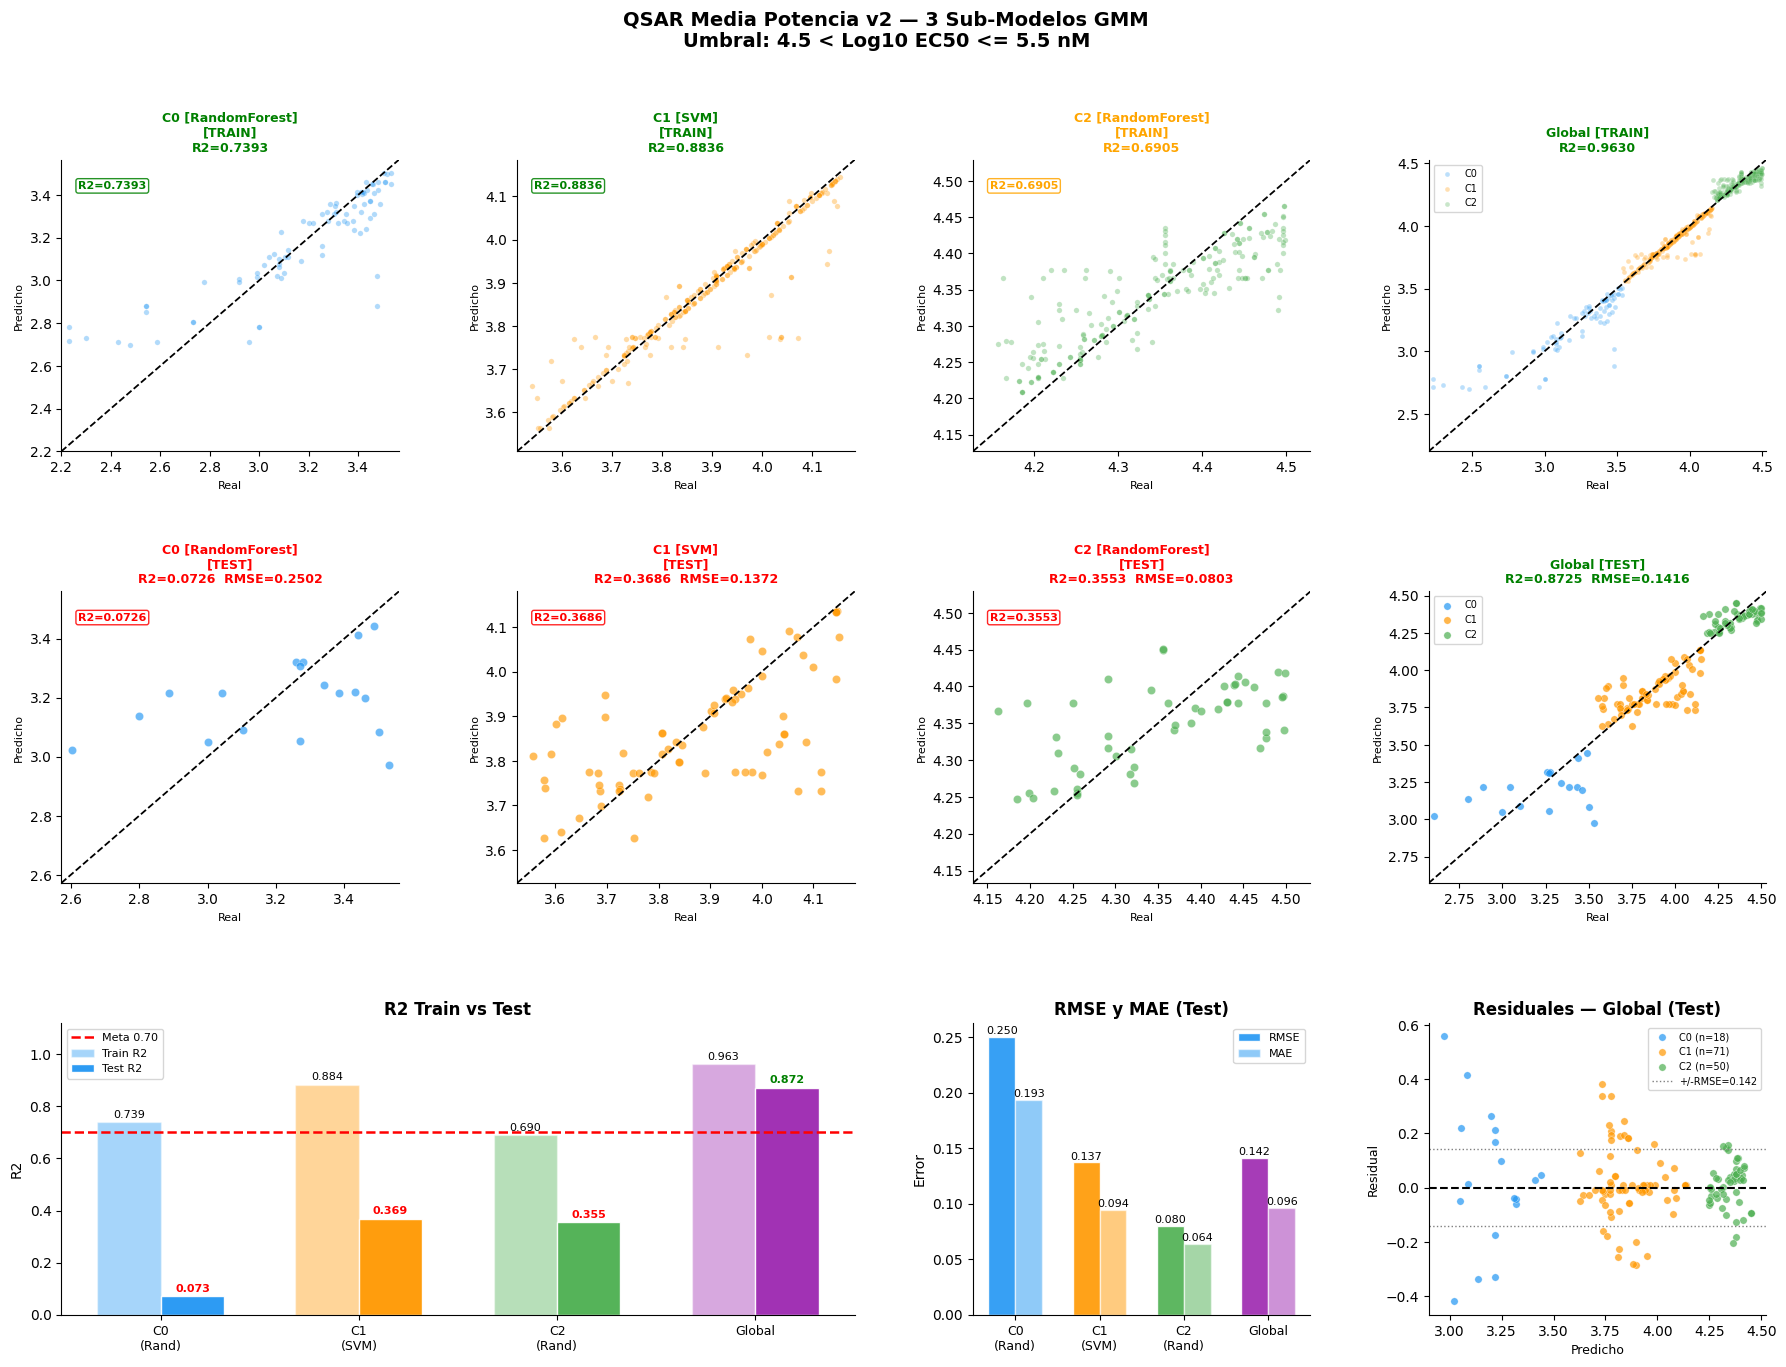

In [11]:
# ── CELDA 11 — Gráfica completa ───────────────────────────────
fig = plt.figure(figsize=(22, 15))
fig.suptitle("QSAR Media Potencia v2 — 3 Sub-Modelos GMM\n"
             "Umbral: 4.5 < Log10 EC50 <= 5.5 nM",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.35)

def scatter_ax(ax, yr, yp, color, title, r2, rmse=None, alpha=0.65, s=35):
    ax.scatter(yr, yp, color=color, alpha=alpha,
               edgecolors="white", linewidth=0.3, s=s)
    lo = min(yr.min(), yp.min()) - 0.03
    hi = max(yr.max(), yp.max()) + 0.03
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Real", fontsize=8); ax.set_ylabel("Predicho", fontsize=8)
    col = "green" if r2 >= 0.70 else ("orange" if r2 >= 0.50 else "red")
    lbl = f"R2={r2:.4f}" + (f"  RMSE={rmse:.4f}" if rmse else "")
    ax.set_title(f"{title}\n{lbl}", fontsize=9, fontweight="bold", color=col)
    ax.text(0.05, 0.90, f"R2={r2:.4f}", transform=ax.transAxes, fontsize=8,
            color=col, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor=col, alpha=0.85))
    ax.spines[["top","right"]].set_visible(False)

for cid in range(3):
    cr = cluster_results[cid]
    scatter_ax(fig.add_subplot(gs[0, cid]), cr["y_tr"], cr["y_pred_tr"],
               PALETTE_C[cid], f"C{cid} [{cr['model_name']}]\n[TRAIN]",
               cr["r2_train"], alpha=0.35, s=15)

ax_gtr = fig.add_subplot(gs[0, 3])
for cid in range(3):
    m = cl_tr == cid
    ax_gtr.scatter(y_tr_all[m], y_pred_tr_global[m], color=PALETTE_C[cid],
                   alpha=0.3, s=12, edgecolors="white", linewidth=0.2, label=f"C{cid}")
lo = min(y_tr_all.min(), y_pred_tr_global.min()) - 0.03
hi = max(y_tr_all.max(), y_pred_tr_global.max()) + 0.03
ax_gtr.plot([lo,hi],[lo,hi],"k--",linewidth=1.3)
ax_gtr.set_xlim(lo,hi); ax_gtr.set_ylim(lo,hi)
ax_gtr.set_xlabel("Real",fontsize=8); ax_gtr.set_ylabel("Predicho",fontsize=8)
col = "green" if r2_gl_tr >= 0.70 else "orange"
ax_gtr.set_title(f"Global [TRAIN]\nR2={r2_gl_tr:.4f}", fontsize=9, fontweight="bold", color=col)
ax_gtr.legend(fontsize=7); ax_gtr.spines[["top","right"]].set_visible(False)

for cid in range(3):
    cr = cluster_results[cid]
    scatter_ax(fig.add_subplot(gs[1, cid]), cr["y_te"], cr["y_pred_te"],
               PALETTE_C[cid], f"C{cid} [{cr['model_name']}]\n[TEST]",
               cr["r2_test"], cr["rmse"])

ax_gte = fig.add_subplot(gs[1, 3])
for cid in range(3):
    m = cl_te == cid
    ax_gte.scatter(y_te_all[m], y_pred_global[m], color=PALETTE_C[cid],
                   alpha=0.7, s=28, edgecolors="white", linewidth=0.3, label=f"C{cid}")
lo = min(y_te_all.min(), y_pred_global.min()) - 0.03
hi = max(y_te_all.max(), y_pred_global.max()) + 0.03
ax_gte.plot([lo,hi],[lo,hi],"k--",linewidth=1.3)
ax_gte.set_xlim(lo,hi); ax_gte.set_ylim(lo,hi)
ax_gte.set_xlabel("Real",fontsize=8); ax_gte.set_ylabel("Predicho",fontsize=8)
col = "green" if r2_gl_te >= 0.70 else "orange"
ax_gte.set_title(f"Global [TEST]\nR2={r2_gl_te:.4f}  RMSE={rmse_gl:.4f}",
                 fontsize=9, fontweight="bold", color=col)
ax_gte.legend(fontsize=7); ax_gte.spines[["top","right"]].set_visible(False)

labels_b = [f"C{i}\n({cluster_results[i]['model_name'][:4]})" for i in range(3)] + ["Global"]
r2_trs_b = [cluster_results[i]["r2_train"] for i in range(3)] + [r2_gl_tr]
r2_tes_b = [cluster_results[i]["r2_test"]  for i in range(3)] + [r2_gl_te]
cols_b   = PALETTE_C + ["#9C27B0"]
x_b, w   = np.arange(4), 0.32

ax_r2 = fig.add_subplot(gs[2, 0:2])
b1 = ax_r2.bar(x_b-w/2, r2_trs_b, w, color=cols_b, alpha=0.4, edgecolor="white", label="Train R2")
b2 = ax_r2.bar(x_b+w/2, r2_tes_b, w, color=cols_b, alpha=0.95, edgecolor="white", label="Test R2")
for bar, val in zip(b1, r2_trs_b):
    ax_r2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(b2, r2_tes_b):
    c = "green" if val >= 0.70 else ("orange" if val >= 0.50 else "red")
    ax_r2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold", color=c)
ax_r2.axhline(0.70, color="red", linestyle="--", linewidth=1.8, label="Meta 0.70")
ax_r2.set_xticks(x_b); ax_r2.set_xticklabels(labels_b, fontsize=9)
ax_r2.set_ylabel("R2"); ax_r2.set_title("R2 Train vs Test", fontweight="bold")
ax_r2.set_ylim(0, 1.12); ax_r2.legend(fontsize=8)
ax_r2.spines[["top","right"]].set_visible(False)

ax_err = fig.add_subplot(gs[2, 2])
rmse_b = [cluster_results[i]["rmse"] for i in range(3)] + [rmse_gl]
mae_b  = [cluster_results[i]["mae"]  for i in range(3)] + [mae_gl]
b3 = ax_err.bar(x_b-w/2, rmse_b, w, color=cols_b, alpha=0.9, edgecolor="white", label="RMSE")
b4 = ax_err.bar(x_b+w/2, mae_b,  w, color=cols_b, alpha=0.5, edgecolor="white", label="MAE")
for bar, val in zip(b3+b4, rmse_b+mae_b):
    ax_err.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax_err.set_xticks(x_b); ax_err.set_xticklabels(labels_b, fontsize=9)
ax_err.set_ylabel("Error"); ax_err.set_title("RMSE y MAE (Test)", fontweight="bold")
ax_err.legend(fontsize=8); ax_err.spines[["top","right"]].set_visible(False)

ax_res = fig.add_subplot(gs[2, 3])
res_gl = y_te_all - y_pred_global
for cid in range(3):
    m = cl_te == cid
    ax_res.scatter(y_pred_global[m], res_gl[m], color=PALETTE_C[cid],
                   alpha=0.7, s=28, edgecolors="white", linewidth=0.3,
                   label=f"C{cid} (n={m.sum()})")
ax_res.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax_res.axhline( rmse_gl, color="gray", linestyle=":", linewidth=1, label=f"+/-RMSE={rmse_gl:.3f}")
ax_res.axhline(-rmse_gl, color="gray", linestyle=":", linewidth=1)
ax_res.set_xlabel("Predicho",fontsize=9); ax_res.set_ylabel("Residual",fontsize=9)
ax_res.set_title("Residuales — Global (Test)", fontweight="bold")
ax_res.legend(fontsize=7); ax_res.spines[["top","right"]].set_visible(False)

plt.savefig(
    "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/media_v2_resultados_completos.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [12]:
# ── CELDA 12 — Guardar modelos ────────────────────────────────
CARPETA = "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos"
os.makedirs(CARPETA, exist_ok=True)
for cid in range(3):
    joblib.dump(cluster_pipes[cid], os.path.join(CARPETA, f"pipe_Media_v2_c{cid}.pkl"))
    joblib.dump(cluster_sels[cid],  os.path.join(CARPETA, f"sel_Media_v2_c{cid}.pkl"))
joblib.dump(vt,  os.path.join(CARPETA, "vt_Media_v2.pkl"))
joblib.dump(gmm, os.path.join(CARPETA, "gmm_Media_v2.pkl"))
print(f"Modelos guardados en {CARPETA}/")
for cid in range(3):
    print(f"  pipe_Media_v2_c{cid}.pkl  ({cluster_results[cid]['model_name']})")

Modelos guardados en /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos/
  pipe_Media_v2_c0.pkl  (RandomForest)
  pipe_Media_v2_c1.pkl  (SVM)
  pipe_Media_v2_c2.pkl  (RandomForest)


In [13]:
# ── CELDA 13 — Resumen final ──────────────────────────────────
print("\n" + "="*65)
print("  RESUMEN FINAL — QSAR Media Potencia v2")
print("="*65)
print(f"  {'':25} {'Train R2':>9} {'Test R2':>9} {'RMSE':>8} {'MAE':>8}")
print("  " + "─"*62)
for cid in range(3):
    cr   = cluster_results[cid]
    flag = "OK" if cr["r2_test"] >= 0.70 else ("~" if cr["r2_test"] >= 0.50 else "")
    print(f"  Cluster {cid} ({cr['model_name']:<15}) "
          f"{cr['r2_train']:>9.4f} {cr['r2_test']:>9.4f} "
          f"{cr['rmse']:>8.4f} {cr['mae']:>8.4f}  {flag}")
flag_gl = "OK" if r2_gl_te >= 0.70 else ""
print(f"  {'Global combinado':<25} {r2_gl_tr:>9.4f} {r2_gl_te:>9.4f} "
      f"{rmse_gl:>8.4f} {mae_gl:>8.4f}  {flag_gl}")
print("="*65)
print(f"\n  Evolucion Media Potencia:")
print(f"    v3 anterior (2 clusters, 5-6)   : R2 = 0.8601")
print(f"    v2 nuevo    (3 clusters, 4.5-5.5): R2 = {r2_gl_te:.4f}  ({r2_gl_te-0.8601:+.4f})")
print(f"\n  Archivos: media_v2_clusters.png, media_v2_resultados_completos.png")
print(f"            modelos guardados en {CARPETA}/")


  RESUMEN FINAL — QSAR Media Potencia v2
                             Train R2   Test R2     RMSE      MAE
  ──────────────────────────────────────────────────────────────
  Cluster 0 (RandomForest   )    0.7393    0.0726   0.2502   0.1932  
  Cluster 1 (SVM            )    0.8836    0.3686   0.1372   0.0944  
  Cluster 2 (RandomForest   )    0.6905    0.3553   0.0803   0.0639  
  Global combinado             0.9630    0.8725   0.1416   0.0962  OK

  Evolucion Media Potencia:
    v3 anterior (2 clusters, 5-6)   : R2 = 0.8601
    v2 nuevo    (3 clusters, 4.5-5.5): R2 = 0.8725  (+0.0124)

  Archivos: media_v2_clusters.png, media_v2_resultados_completos.png
            modelos guardados en /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos/


In [14]:
# ============================================================
# CELDA PREDICTOR — MEDIA POTENCIA (v3)
# Pegar al FINAL del notebook qsar_media_v3
#
# Variables que usa de la sesión (ya existen tras ejecutar v3):
#   pipe0, pipe1       → sub-modelos de Cluster 0 y Cluster 1
#   sel0, sel1         → selectores de features por cluster
#   vt                 → VarianceThreshold ajustado
#   gmm                → GaussianMixture(n_components=2) ajustado
#   cluster_results    → dict con métricas por cluster
#
# Genera 3 CSV de predicciones (uno por conjunto de moléculas)
# en la carpeta de resultados configurada.
# ============================================================

import os, joblib
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

In [15]:
# ── CONFIGURACIÓN DE CONJUNTOS ─────────────
POTENCIA = "Media"

CONJUNTOS = [
    {
        "nombre":     "cannabaceae_complete",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/cannabaceae_phytochemicals_complete.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_cannabaceae_complete.csv",
        "sep":        ",",
        "col_smiles": "smiles",
        "col_nombre": "molecule_name",
    },
    {
        "nombre":     "cannabaceae_hoja1",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/Cannabaceae_molecules(Hoja1).csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_cannabaceae_hoja1.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },
    {
        "nombre":     "terpenos",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/terpenos.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_terpenos.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "molecule_name",
    },
{
        "nombre":     "molecules3",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/molecules3.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_moleculas.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },]

CARPETA_MODELOS = "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos"
os.makedirs(CARPETA_MODELOS, exist_ok=True)

# ── Adaptar modelos guardados para la predicción ─────────────────
# The actual trained models and selectors are in cluster_pipes and cluster_sels
# from the previous cells (Cell 9).
pipes_dict = cluster_pipes
sels_dict  = cluster_sels
N_CLUSTERS = len(cluster_pipes) # Dynamically get the number of clusters (which is 3)

# The models were already saved in CELDA 12. Removing redundant saving here.

print(f"✅ Modelos {POTENCIA} cargados para predicción.")
print(f"   Clusters detectados: {N_CLUSTERS}")
print(f"   GMM medias: {sorted(gmm.means_.flatten())}")
for cid in range(N_CLUSTERS):
    print(f"   Cluster {cid} → {cluster_results[cid]['model_name']}")


# ── Función de descriptores (corrected from previous error) ─────────────────────
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        # Corrected: using list() directly on bit vectors
        fp_ecfp4 = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)), dtype=float)
        fp_ecfp6 = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 3, 1024)), dtype=float)
        fp_maccs = np.array(list(rdMolDescriptors.GetMACCSKeysFingerprint(mol)), dtype=float)
        desc = [
            Descriptors.ExactMolWt(mol),        Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),              Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),     Descriptors.NumRotatableBonds(mol),
            Descriptors.RingCount(mol),         Descriptors.NumAromaticRings(mol),
            Descriptors.FractionCSP3(mol),      Descriptors.NumAliphaticRings(mol),
            Descriptors.NumHeteroatoms(mol),    Descriptors.HeavyAtomCount(mol),
            Descriptors.NumSaturatedRings(mol),
            rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
            rdMolDescriptors.CalcNumSpiroAtoms(mol),
        ]
        return np.concatenate([fp_ecfp4, fp_ecfp6, fp_maccs, desc])
    except Exception as e:
        print(f"Error calculating descriptors for SMILES {smiles}: {e}")
        return None

def calcular_features(smiles_list):
    X, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        d = get_descriptors(smi)
        if d is not None:
            X.append(d); valid_idx.append(i)
    return np.array(X), valid_idx

# ── CI por dispersión entre estimadores ──────────────
def predict_ci(pipe, X, z=1.96):
    model  = pipe.named_steps["model"]
    scaler = pipe.named_steps["scaler"]
    X_sc   = scaler.transform(X)
    try:
        # RandomForest / ExtraTrees
        if hasattr(model, 'estimators_'):
             preds_ind = np.array([t.predict(X_sc) for t in model.estimators_])
        # GradientBoosting: for staged_predict
        elif hasattr(model, 'staged_predict'):
            stages    = list(model.staged_predict(X_sc))
            preds_ind = np.array(stages[max(0, len(stages) - 100):])
        else: # For other models like SVR, just return single prediction and zeros for CI
            mean_p = model.predict(X_sc)
            return mean_p, mean_p, mean_p # No CI for non-ensemble models this way
    except AttributeError: # Fallback for models without estimators_ or staged_predict
        mean_p = model.predict(X_sc)
        return mean_p, mean_p, mean_p # No CI for non-ensemble models this way

    mean_p = preds_ind.mean(axis=0)
    std_p  = preds_ind.std(axis=0)
    return mean_p, mean_p - z * std_p, mean_p + z * std_p

# ── Reordenamiento de clusters GMM (ascendente por media) ────
order = np.argsort(gmm.means_.flatten())
remap = {old: new for new, old in enumerate(order)}

def asignar_cluster(pred_estimate):
    raw = gmm.predict(pred_estimate.reshape(-1, 1))
    return np.array([remap[l] for l in raw])

# ── Cargar CSV con detección automática ─────────────
def cargar_csv(ruta, sep, col_smi, col_nom):
    try:
        df = pd.read_csv(ruta, sep=sep)
        if df.shape[1] == 1:                     # separador incorrecto
            sep2 = "," if sep == ";" else ";"
            df   = pd.read_csv(ruta, sep=sep2)
            print(f"  ⚠️  Separador ajustado a '{sep2}'")
    except Exception as e:
        raise RuntimeError(f"No se pudo leer {ruta}: {e}")

    df.columns = df.columns.str.strip()

    # Detección automática de columnas
    for p in ['smiles', 'Smiles', 'SMILES']:
        if p in df.columns: col_smi = p; break
    for p in ['molecule_name', 'Molecule_name', 'Molecule_Name', 'name', 'Name']:
        if p in df.columns: col_nom = p; break

    print(f"  Columnas → SMILES: '{col_smi}'   Nombre: '{col_nom}'")
    return df, col_smi, col_nom

# ── Procesar cada conjunto ────────────────
for cfg in CONJUNTOS:
    print(f"\n{'='*60}")
    print(f"  {POTENCIA} — {cfg['nombre']}")
    print(f"{'='*60}")

    try:
        df_new, col_smi, col_nom = cargar_csv(
            cfg['entrada'], cfg['sep'], cfg['col_smiles'], cfg['col_nombre']
        )
    except RuntimeError as e:
        print(f"  ❌ {e}"); continue

    print(f"  Moléculas cargadas: {len(df_new)}")

    # Calcular descriptores
    X_raw, valid_idx = calcular_features(df_new[col_smi].tolist())
    df_valid = df_new.iloc[valid_idx].reset_index(drop=True)
    n_inv    = len(df_new) - len(df_valid)
    if n_inv:
        print(f"  ⚠️  {n_inv} SMILES inválidos descartados")
    print(f"  Moléculas válidas: {len(df_valid)}")

    # VarianceThreshold
    X_vt_new = vt.transform(X_raw)

    # Aplicar limpieza por correlación
    # 'keep' variable is determined in Cell 6, make sure it's accessible.
    X_clean_new = X_vt_new[:, keep]

    # Estimación inicial del target para GMM
    # Promedio de predicciones de todos sub-modelos
    preds_for_gmm_estimation = []
    for cid in range(N_CLUSTERS):
        X_sel_tmp = sels_dict[cid].transform(X_clean_new)
        sc_tmp    = pipes_dict[cid].named_steps["scaler"]
        md_tmp    = pipes_dict[cid].named_steps["model"]
        X_sc_tmp  = sc_tmp.transform(X_sel_tmp)
        # Use predict for all models to get an estimate for GMM
        preds_for_gmm_estimation.append(md_tmp.predict(X_sc_tmp))

    pred_estimate = np.column_stack(preds_for_gmm_estimation).mean(axis=1)
    cluster_new   = asignar_cluster(pred_estimate)

    print(f"  Clusters asignados:")
    for cid in range(N_CLUSTERS):
        n_cid = (cluster_new == cid).sum()
        print(f"    Cluster {cid} ({cluster_results[cid]['model_name']}): "
              f"{n_cid} moléculas")

    # Predicción final con CI
    mean_out  = np.zeros(len(df_valid))
    lower_out = np.zeros(len(df_valid))
    upper_out = np.zeros(len(df_valid))

    for cid in range(N_CLUSTERS):
        mask = cluster_new == cid
        if mask.sum() == 0:
            continue
        X_sel = sels_dict[cid].transform(X_clean_new[mask])
        m, lo, up = predict_ci(pipes_dict[cid], X_sel)
        mean_out[mask]  = m
        lower_out[mask] = lo
        upper_out[mask] = up
        print(f"    Cluster {cid}: pred_media={m.mean():.3f}  "
              f"CI_width={(up - lo).mean():.3f}  "
              f"rango=[{m.min():.3f}, {m.max():.3f}]")

    # Guardar CSV
    df_out = pd.DataFrame({
        "SMILES":                   df_valid[col_smi].values,
        "Molecule_name":            df_valid[col_nom].values,
        "Potency_Model":            POTENCIA,
        "Cluster_Assigned":         cluster_new,
        "Predicted_Log10_Value_nM": mean_out,
        "Lower_CI_95":              lower_out,
        "Upper_CI_95":              upper_out,
        "CI_95_Width":              upper_out - lower_out,
    })

    os.makedirs(os.path.dirname(cfg['salida']), exist_ok=True)
    df_out.to_csv(cfg['salida'], sep=";", index=False, float_format="%.6f")

    print(f"\n  ✅ Guardado: {cfg['salida']}")
    print(f"  Pred. media global: {mean_out.mean():.4f} Log10 nM")
    print(f"  CI width promedio : {(upper_out - lower_out).mean():.4f}")

    print(f"\n  Top 5 moléculas más activas (menor Log10 EC50):")
    top5 = df_out.nsmallest(5, "Predicted_Log10_Value_nM")
    print(top5[["Molecule_name", "Cluster_Assigned",
                "Predicted_Log10_Value_nM", "CI_95_Width"]].to_string(index=False))

# ── Resumen final ───────────────────
print(f"\n{'='*60}")
print(f"✅ Media Potencia — todos los conjuntos procesados.")
print(f"{'='*60}")
print(f"\nArchivos generados:")
for cfg in CONJUNTOS:
    print(f"  → {os.path.basename(cfg['salida'])}")
print(f"\nCarpeta: {CARPETA_MODELOS}/")

✅ Modelos Media cargados para predicción.
   Clusters detectados: 3
   GMM medias: [np.float64(3.350246501818414), np.float64(3.8936942547249735), np.float64(4.335869085619006)]
   Cluster 0 → RandomForest
   Cluster 1 → SVM
   Cluster 2 → RandomForest

  Media — cannabaceae_complete
  Columnas → SMILES: 'smiles'   Nombre: 'molecule_name'
  Moléculas cargadas: 597


[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerator
[21:17:59] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 597
  Clusters asignados:
    Cluster 0 (RandomForest): 0 moléculas
    Cluster 1 (SVM): 597 moléculas
    Cluster 2 (RandomForest): 0 moléculas
    Cluster 1: pred_media=3.876  CI_width=0.000  rango=[3.623, 4.127]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_cannabaceae_complete.csv
  Pred. media global: 3.8760 Log10 nM
  CI width promedio : 0.0000

  Top 5 moléculas más activas (menor Log10 EC50):
    Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
      Epicatechin                 1                  3.622924          0.0
         Catechin                 1                  3.622924          0.0
         Catechin                 1                  3.622924          0.0
      Epicatechin                 1                  3.622924          0.0
Decanoylcarnitine                 1                  3.754268          0.0

  Media — cannabaceae_hoja1
  Columnas → SMILES: 'Smiles'   Nombre: '

[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerator
[21:18:03] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 45
  Clusters asignados:
    Cluster 0 (RandomForest): 0 moléculas
    Cluster 1 (SVM): 45 moléculas
    Cluster 2 (RandomForest): 0 moléculas
    Cluster 1: pred_media=3.926  CI_width=0.000  rango=[3.865, 3.993]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_cannabaceae_hoja1.csv
  Pred. media global: 3.9263 Log10 nM
  CI width promedio : 0.0000

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
         CBDA                 1                  3.864544          0.0
         CBDA                 1                  3.864544          0.0
         CBDA                 1                  3.864544          0.0
         CBDA                 1                  3.864544          0.0
         THCV                 1                  3.903002          0.0

  Media — terpenos
  ⚠️  Separador ajustado a ','
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecul

[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerator
[21:18:04] DEPRECATION WARNING: please use MorganGenerat

  ⚠️  915 SMILES inválidos descartados
  Moléculas válidas: 84
  Clusters asignados:
    Cluster 0 (RandomForest): 0 moléculas
    Cluster 1 (SVM): 84 moléculas
    Cluster 2 (RandomForest): 0 moléculas
    Cluster 1: pred_media=3.816  CI_width=0.000  rango=[3.783, 3.886]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_terpenos.csv
  Pred. media global: 3.8159 Log10 nM
  CI width promedio : 0.0000

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
    Δ3-carene                 1                  3.782781          0.0
  alfa-Pineno                 1                  3.787474          0.0
  alfa-Pineno                 1                  3.787474          0.0
  alfa-Pineno                 1                  3.787474          0.0
  alfa-Pineno                 1                  3.787474          0.0

  Media — molecules3
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecu

[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerator
[21:18:06] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 204
  Clusters asignados:
    Cluster 0 (RandomForest): 0 moléculas
    Cluster 1 (SVM): 204 moléculas
    Cluster 2 (RandomForest): 0 moléculas
    Cluster 1: pred_media=3.879  CI_width=0.000  rango=[3.590, 4.130]

  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_media_moleculas.csv
  Pred. media global: 3.8794 Log10 nM
  CI width promedio : 0.0000

  Top 5 moléculas más activas (menor Log10 EC50):
                                                Molecule_name  Cluster_Assigned  Predicted_Log10_Value_nM  CI_95_Width
                             2,6-Di-tert-butyl-4-methylphenol                 1                  3.590251          0.0
                                                   Pyrogallol                 1                  3.632753          0.0
Phenol, 4-[(dimethylamino)methyl]-2,6-bis(1,1-dimethylethyl)-                 1                  3.674765          0.0
                                                       